# Notebook 03 — Regressiemodellen deel 1
## Lineaire regressie · Polynomiale regressie · KNN · Ridge · Lasso · ElasticNet

**Project:** ML Regressie op YouTube trending video data  
 
**Doel van deze notebook:** Zes regressiemodellen trainen, evalueren en vergelijken op `log_views`.

---

### Aanpak
We laden de preprocessed data en preprocessor uit notebook 02 en trainen elk model in een **Pipeline**.  
Elk model wordt beoordeeld op drie metrics:

| Metric | Wat meet het? | Hoe lezen? |
|---|---|---|
| **R²** | Hoeveel variatie verklaart het model? | 1.0 = perfect, 0 = niet beter dan gemiddelde |
| **MAE** | Gemiddelde absolute fout | Zelfde eenheid als target — lager = beter |
| **RMSE** | Wortelvariante van gemiddelde kwadratische fout | Straft grote fouten harder — lager = beter |

## 1. Setup & data laden

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

import os
os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/models', exist_ok=True)

# Data laden
with open('../output/models/train_test_data.pkl', 'rb') as f:
    data = pickle.load(f)

with open('../output/models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f'Trainset: {X_train.shape[0]} rijen × {X_train.shape[1]} features')
print(f'Testset:  {X_test.shape[0]} rijen × {X_test.shape[1]} features')
print(f'Target (log_views) — gemiddelde: {y_train.mean():.3f}, std: {y_train.std():.3f}')

## 2. Hulpfuncties

We definiëren twee herbruikbare functies:
- `evaluate_model`: berekent R², MAE en RMSE op de testset
- `cross_validate_model`: 5-fold cross-validatie op de trainset om overfitting te detecteren

In [2]:
results = {}  # bewaar alle resultaten voor de eindvergelijking

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    cv_r2 = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2').mean()

    results[name] = {'R²': r2, 'MAE': mae, 'RMSE': rmse, 'CV R² (train)': cv_r2}

    print(f'{name}')
    print(f'  R²             = {r2:.4f}')
    print(f'  MAE            = {mae:.4f}')
    print(f'  RMSE           = {rmse:.4f}')
    print(f'  CV R² (train)  = {cv_r2:.4f}  {"⚠️ mogelijke overfitting" if cv_r2 - r2 > 0.05 else "✓"}')
    print()
    return pipeline

print('Hulpfuncties klaar.')

Hulpfuncties klaar.


## 3. Baseline — DummyRegressor

Elk ML-project start met een **baseline**: het domste model dat je kunt bedenken.  
Hier voorspelt de DummyRegressor altijd het gemiddelde van de trainset.

> Als ons model de baseline niet verslaat, hebben we een probleem.

De baseline-R² zal 0.00 zijn per definitie — dat is ons vertrekpunt.

In [3]:
baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

baseline_pipe = evaluate_model('Baseline (gemiddelde)', baseline_pipe, X_train, y_train, X_test, y_test)

Baseline (gemiddelde)
  R²             = -0.0001
  MAE            = 1.8855
  RMSE           = 2.2967
  CV R² (train)  = -0.0002  ✓



## 4. Lineaire regressie

**Hoe werkt het?**  
Lineaire regressie zoekt de beste rechte lijn (of hypervlak in meerdere dimensies) door de data.  
Het minimaliseert de som van de gekwadrateerde fouten tussen de voorspelling en de werkelijke waarde.

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

**Voordelen:** snel, interpreteerbaar, goede baseline voor complexere modellen  
**Nadelen:** veronderstelt lineaire relaties — werkt slecht bij niet-lineaire patronen

In [4]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipe = evaluate_model('Lineaire regressie', lr_pipe, X_train, y_train, X_test, y_test)

Lineaire regressie
  R²             = 0.7039
  MAE            = 0.9585
  RMSE           = 1.2497
  CV R² (train)  = 0.6912  ✓



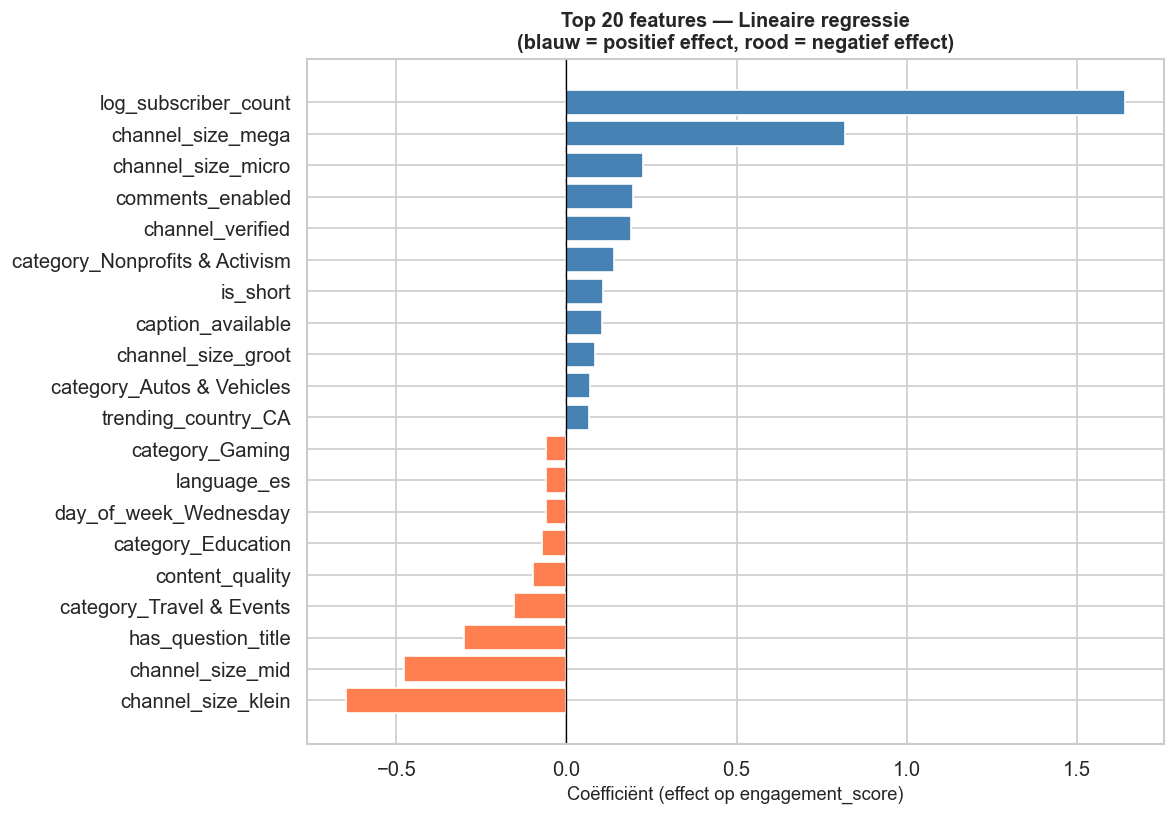

In [5]:
# Coëfficiënten visualiseren — welke features tellen het meest?
feature_names = data['feature_names']
coefs = lr_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
top20 = coef_df.nlargest(20, 'abs_coef').sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if c > 0 else 'coral' for c in top20['coef']]
ax.barh(top20['feature'], top20['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coëfficiënt (effect op engagement_score)', fontsize=11)
ax.set_title('Top 20 features — Lineaire regressie\n(blauw = positief effect, rood = negatief effect)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/03_lr_coefficienten.png')
plt.show()

## 5. Polynomiale regressie

**Hoe werkt het?**  
Polynomiale regressie breidt lineaire regressie uit door extra features toe te voegen: kwadratische termen ($x^2$), cubische termen ($x^3$), en interacties tussen features ($x_1 \cdot x_2$).

Dit laat het model toe **gebogen verbanden** te leren — denk aan: een video met een gemiddelde duur scoort beter dan een zeer korte of zeer lange video.

**Let op overfitting:** hogere graden passen de traindata steeds beter aan, maar generaliseren slechter naar nieuwe data.  
We vergelijken degree=2 en degree=3 op de testset.

> ⚠️ Polynomiale regressie met veel features genereert **enorm veel** nieuwe kolommen. We beperken ons tot de numerieke features om dit beheersbaar te houden.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features   = data['numerical_features']
categorical_features = data['categorical_features']
binary_features      = data['binary_features']

for degree in [2, 3]:
    # Aparte preprocessor met PolynomialFeatures enkel op numerieke features
    poly_preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler()),
            ('poly',   PolynomialFeatures(degree=degree, include_bias=False))
        ]), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

    poly_pipe = Pipeline([
        ('preprocessor', poly_preprocessor),
        ('model', LinearRegression())
    ])

    poly_pipe = evaluate_model(f'Polynomiale regressie (degree={degree})',
                               poly_pipe, X_train, y_train, X_test, y_test)

Polynomiale regressie (degree=2)
  R²             = 0.7112
  MAE            = 0.9257
  RMSE           = 1.2342
  CV R² (train)  = 0.6981  ✓



Polynomiale regressie (degree=3)
  R²             = 0.7077
  MAE            = 0.9321
  RMSE           = 1.2416
  CV R² (train)  = 0.6929  ✓



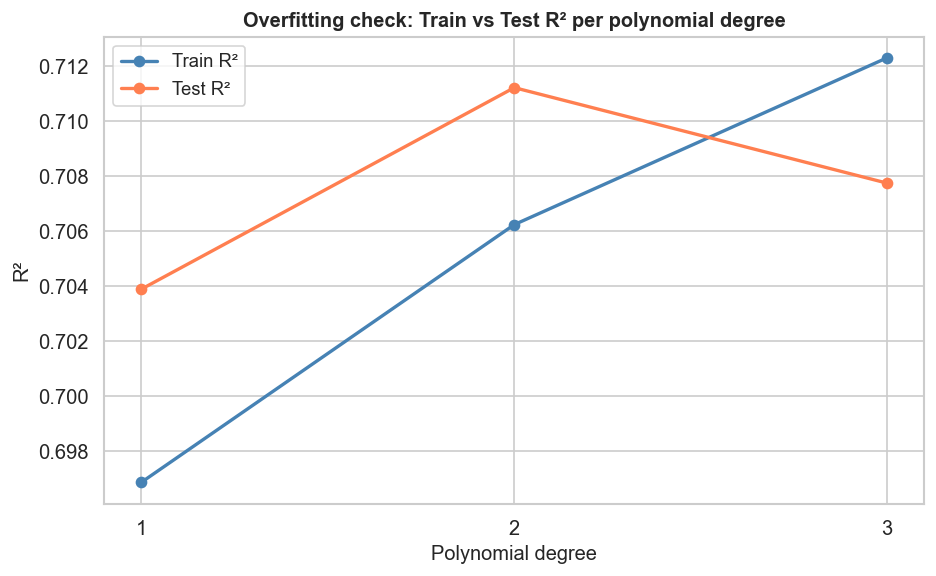

Als train R² stijgt maar test R² daalt → overfitting.


In [7]:
# Overfitting visualiseren: train R² vs test R² per degree
degrees = [1, 2, 3]
train_scores, test_scores = [], []

for degree in degrees:
    if degree == 1:
        prep = preprocessor
    else:
        prep = ColumnTransformer(transformers=[
            ('num', Pipeline([
                ('scaler', StandardScaler()),
                ('poly',   PolynomialFeatures(degree=degree, include_bias=False))
            ]), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
            ('bin', 'passthrough', binary_features)
        ])

    pipe = Pipeline([('preprocessor', prep), ('model', LinearRegression())])
    pipe.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test,  pipe.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, train_scores, 'o-', color='steelblue', label='Train R²', linewidth=2)
ax.plot(degrees, test_scores,  'o-', color='coral',     label='Test R²',  linewidth=2)
ax.set_xlabel('Polynomial degree', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Overfitting check: Train vs Test R² per polynomial degree',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(degrees)
plt.tight_layout()
plt.savefig('../output/figures/03_poly_overfitting.png')
plt.show()
print('Als train R² stijgt maar test R² daalt → overfitting.')

## 6. KNN-regressie

**Hoe werkt het?**  
KNN (K-Nearest Neighbors) maakt geen model in de traditionele zin — het onthoudt alle traindata.  
Bij een nieuwe video zoekt het de **k meest gelijkaardige video's** in de trainset en berekent het gemiddelde van hun engagement scores.

**Keuze van k:**
- **Klein k** (bv. k=1): model volgt de data heel nauw → overfitting
- **Groot k** (bv. k=100): model middelt te veel → underfitting

We zoeken de optimale k via cross-validatie.

In [8]:
# Optimale k zoeken via cross-validatie
k_values = [1, 3, 5, 7, 10, 15, 20, 30, 50]
cv_scores = []

for k in k_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()
    cv_scores.append(score)
    print(f'  k={k:>3}  CV R²={score:.4f}')

best_k = k_values[np.argmax(cv_scores)]
print(f'\nBeste k: {best_k} (CV R²={max(cv_scores):.4f})')

  k=  1  CV R²=0.2894


  k=  3  CV R²=0.5397


  k=  5  CV R²=0.5884


  k=  7  CV R²=0.6087


  k= 10  CV R²=0.6280


  k= 15  CV R²=0.6404


  k= 20  CV R²=0.6437


  k= 30  CV R²=0.6446


  k= 50  CV R²=0.6415

Beste k: 30 (CV R²=0.6446)


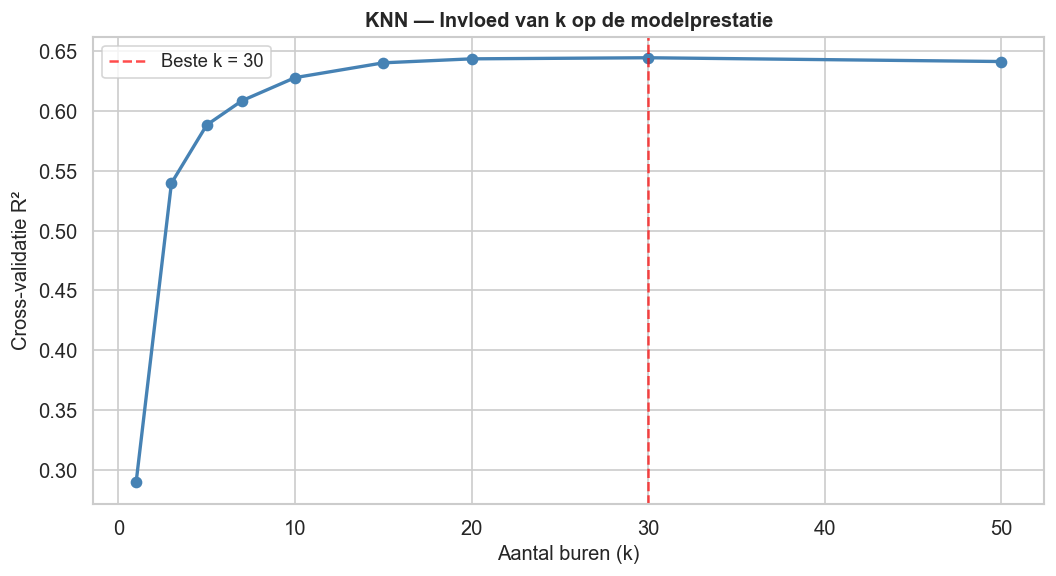

KNN (k=30)
  R²             = 0.6482
  MAE            = 1.0428
  RMSE           = 1.3622
  CV R² (train)  = 0.6446  ✓



In [9]:
# Visualiseer de k-curve
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, cv_scores, 'o-', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Beste k = {best_k}')
ax.set_xlabel('Aantal buren (k)', fontsize=12)
ax.set_ylabel('Cross-validatie R²', fontsize=12)
ax.set_title('KNN — Invloed van k op de modelprestatie', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../output/figures/03_knn_k_curve.png')
plt.show()

# Beste model evalueren
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=best_k))
])
knn_pipe = evaluate_model(f'KNN (k={best_k})', knn_pipe, X_train, y_train, X_test, y_test)

## 7. Ridge regressie

**Hoe werkt het?**  
Ridge is lineaire regressie met een **strafterm** (L2-regularisatie).  
Grote coëfficiënten worden bestraft — het model wordt gedwongen om de gewichten klein te houden.

$$\text{Ridge loss} = \sum(y - \hat{y})^2 + \alpha \sum \beta_j^2$$

De parameter **alpha** bepaalt hoe streng de bestraffing is:
- **alpha = 0**: identiek aan gewone lineaire regressie
- **alpha groot**: coëfficiënten worden sterk naar nul geduwd

We gebruiken `RidgeCV` om de beste alpha automatisch te vinden.

In [10]:
alphas = [0.01, 0.1, 1.0, 10, 100, 1000]

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=alphas, cv=5))
])

ridge_pipe.fit(X_train, y_train)
best_alpha_ridge = ridge_pipe.named_steps['model'].alpha_
print(f'Beste alpha (Ridge): {best_alpha_ridge}')

ridge_pipe = evaluate_model(f'Ridge (alpha={best_alpha_ridge})',
                            ridge_pipe, X_train, y_train, X_test, y_test)

Beste alpha (Ridge): 100.0


Ridge (alpha=100.0)
  R²             = 0.7022
  MAE            = 0.9626
  RMSE           = 1.2532
  CV R² (train)  = 0.6911  ✓



## 8. Lasso regressie

**Hoe werkt het?**  
Lasso gebruikt een **L1-strafterm**: in plaats van coëfficiënten te verkleinen, dwingt het sommige coëfficiënten naar **exact nul**.

$$\text{Lasso loss} = \sum(y - \hat{y})^2 + \alpha \sum |\beta_j|$$

Dit maakt Lasso een **ingebouwde feature selector**: features met coëfficiënt = 0 worden volledig genegeerd.  
Bij veel irrelevante features is Lasso vaak beter dan Ridge.

In [11]:
lasso_cv_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(alphas=alphas, cv=5, max_iter=10000))
])

lasso_cv_pipe.fit(X_train, y_train)
best_alpha_lasso = lasso_cv_pipe.named_steps['model'].alpha_
print(f'Beste alpha (Lasso): {best_alpha_lasso}')

lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=best_alpha_lasso, max_iter=10000))
])
lasso_pipe = evaluate_model(f'Lasso (alpha={best_alpha_lasso})',
                            lasso_pipe, X_train, y_train, X_test, y_test)

Beste alpha (Lasso): 0.01


Lasso (alpha=0.01)
  R²             = 0.7027
  MAE            = 0.9641
  RMSE           = 1.2523
  CV R² (train)  = 0.6929  ✓



Features behouden (coef ≠ 0): 9
Features uitgeschakeld (coef = 0): 67


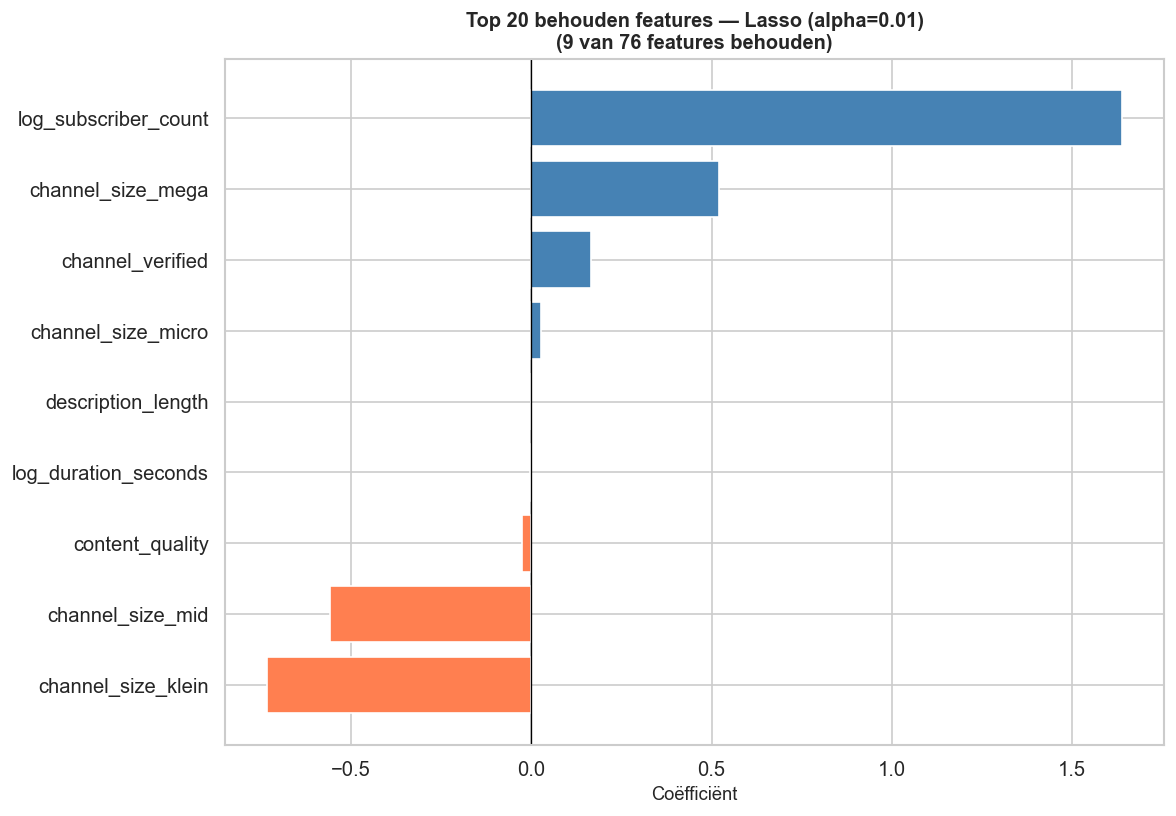

In [12]:
# Welke features zette Lasso op nul?
lasso_pipe.fit(X_train, y_train)
lasso_coefs = lasso_pipe.named_steps['model'].coef_
n_zero    = np.sum(lasso_coefs == 0)
n_nonzero = np.sum(lasso_coefs != 0)

print(f'Features behouden (coef ≠ 0): {n_nonzero}')
print(f'Features uitgeschakeld (coef = 0): {n_zero}')

# Top behouden features
lasso_df = pd.DataFrame({'feature': feature_names, 'coef': lasso_coefs})
lasso_df = lasso_df[lasso_df['coef'] != 0].copy()
lasso_df['abs_coef'] = lasso_df['coef'].abs()
top_lasso = lasso_df.nlargest(20, 'abs_coef').sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if c > 0 else 'coral' for c in top_lasso['coef']]
ax.barh(top_lasso['feature'], top_lasso['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coëfficiënt', fontsize=11)
ax.set_title(f'Top 20 behouden features — Lasso (alpha={best_alpha_lasso})\n'
             f'({n_nonzero} van {len(feature_names)} features behouden)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/03_lasso_coefficienten.png')
plt.show()

## 9. ElasticNet

**Hoe werkt het?**  
ElasticNet combineert de straftermen van Ridge (L2) én Lasso (L1):

$$\text{ElasticNet loss} = \sum(y - \hat{y})^2 + \alpha \left[ \rho \sum |\beta_j| + \frac{1-\rho}{2} \sum \beta_j^2 \right]$$

De parameter **l1_ratio** (= $\rho$) bepaalt de balans:
- l1_ratio = 1 → puur Lasso
- l1_ratio = 0 → puur Ridge
- l1_ratio = 0.5 → gelijke mix

ElasticNet is nuttig wanneer er **groepen van gecorreleerde features** zijn.

In [13]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

en_cv_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, max_iter=10000))
])

en_cv_pipe.fit(X_train, y_train)
best_alpha_en   = en_cv_pipe.named_steps['model'].alpha_
best_l1_ratio   = en_cv_pipe.named_steps['model'].l1_ratio_
print(f'Beste alpha:    {best_alpha_en}')
print(f'Beste l1_ratio: {best_l1_ratio}')

en_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(alpha=best_alpha_en, l1_ratio=best_l1_ratio, max_iter=10000))
])
en_pipe = evaluate_model(f'ElasticNet (α={best_alpha_en}, l1={best_l1_ratio})',
                         en_pipe, X_train, y_train, X_test, y_test)

Beste alpha:    0.01
Beste l1_ratio: 0.7
ElasticNet (α=0.01, l1=0.7)
  R²             = 0.7033
  MAE            = 0.9631
  RMSE           = 1.2510
  CV R² (train)  = 0.6930  ✓



## 10. Vergelijkingstabel & visualisatie

Nu plaatsen we alle modellen naast elkaar.  
We kijken naar:
1. **Test R²** — hoe goed voorspelt het model op ongeziene data?
2. **CV R² vs Test R²** — is er overfitting?
3. **MAE en RMSE** — hoe groot zijn de fouten in absolute termen?

In [14]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('R²', ascending=False)
print('Vergelijkingstabel — alle modellen:')
display(results_df)

Vergelijkingstabel — alle modellen:


,R²,MAE,RMSE,CV R² (train)
Polynomiale regressie (degree=2),0.7112,0.9257,1.2342,0.6981
Polynomiale regressie (degree=3),0.7077,0.9321,1.2416,0.6929
Lineaire regressie,0.7039,0.9585,1.2497,0.6912
"ElasticNet (α=0.01, l1=0.7)",0.7033,0.9631,1.2510,0.6930
Lasso (alpha=0.01),0.7027,0.9641,1.2523,0.6929
Ridge (alpha=100.0),0.7022,0.9626,1.2532,0.6911
KNN (k=30),0.6482,1.0428,1.3622,0.6446
Baseline (gemiddelde),-0.0001,1.8855,2.2967,-0.0002


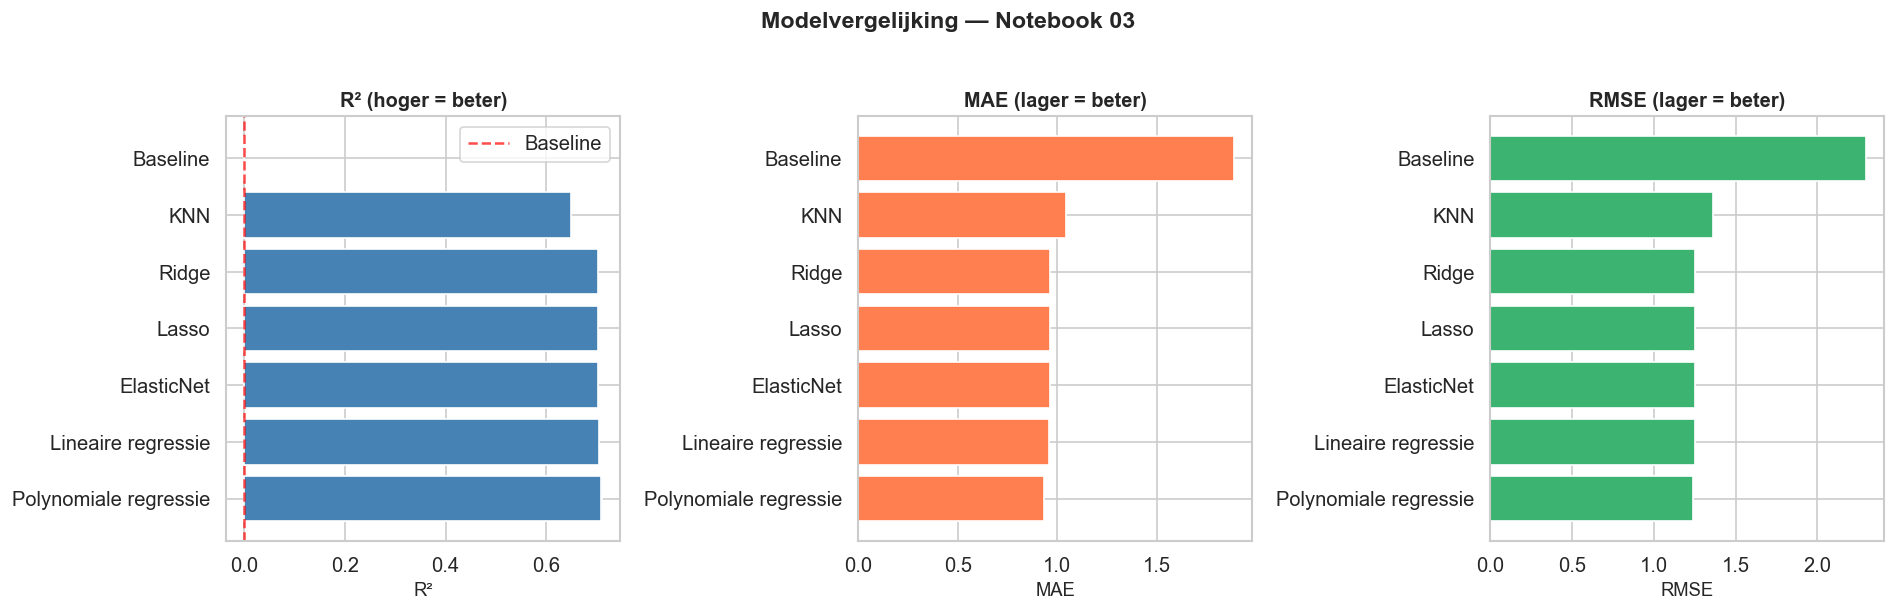

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = results_df.index.tolist()
short_names = [n.split('(')[0].strip() for n in model_names]

# R²
axes[0].barh(short_names, results_df['R²'], color='steelblue')
axes[0].axvline(results_df.loc['Baseline (gemiddelde)', 'R²'],
                color='red', linestyle='--', alpha=0.7, label='Baseline')
axes[0].set_xlabel('R²', fontsize=11)
axes[0].set_title('R² (hoger = beter)', fontsize=12, fontweight='bold')
axes[0].legend()

# MAE
axes[1].barh(short_names, results_df['MAE'], color='coral')
axes[1].set_xlabel('MAE', fontsize=11)
axes[1].set_title('MAE (lager = beter)', fontsize=12, fontweight='bold')

# RMSE
axes[2].barh(short_names, results_df['RMSE'], color='mediumseagreen')
axes[2].set_xlabel('RMSE', fontsize=11)
axes[2].set_title('RMSE (lager = beter)', fontsize=12, fontweight='bold')

plt.suptitle('Modelvergelijking — Notebook 03', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/03_modelvergelijking.png')
plt.show()

In [ ]:
# Predicted vs Actual voor het beste model
best_name = results_df.index[0]
print(f'Beste model: {best_name}')

# Haal het beste model op op basis van naam
pipe_map = {
    'Lineaire regressie': lr_pipe,
    f'KNN (k={best_k})':  knn_pipe,
    f'Ridge (alpha={best_alpha_ridge})': ridge_pipe,
    f'Lasso (alpha={best_alpha_lasso})': lasso_pipe,
    f'ElasticNet (α={best_alpha_en}, l1={best_l1_ratio})': en_pipe,
}

best_pipe = pipe_map.get(best_name, lr_pipe)
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_best, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfecte voorspelling')
ax.set_xlabel('Werkelijke log_views', fontsize=11)
ax.set_ylabel('Voorspelde log_views', fontsize=11)
ax.set_title(f'Predicted vs Actual — {best_name.split("(")[0].strip()}',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/figures/03_predicted_vs_actual.png')
plt.show()

In [17]:
# Resultaten opslaan voor notebook 05
with open('../output/models/results_nb03.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Resultaten opgeslagen in output/models/results_nb03.pkl')

Resultaten opgeslagen in output/models/results_nb03.pkl


## 11. Samenvatting

| Model | Sterkte | Zwakte |
|---|---|---|
| **Baseline** | Referentiepunt | Voorspelt altijd hetzelfde |
| **Lineaire regressie** | Snel, interpreteerbaar | Alleen lineaire verbanden |
| **Polynomiale regressie** | Vangt gebogen verbanden | Snel overfitting bij hoge degree |
| **KNN** | Geen aannames over verdeling | Traag bij grote datasets, gevoelig voor schaal |
| **Ridge** | Stabiel bij multicollineariteit | Houdt alle features |
| **Lasso** | Ingebouwde feature selectie | Kan relevante features uitsluiten bij hoge alpha |
| **ElasticNet** | Combineert Ridge + Lasso | Twee parameters te tunen |

---

**Volgende stap:** Notebook 04 — Tree-based modellen (Decision Tree, Random Forest, XGBoost)